# Portable QEM: counts, calibration and exact reopening

This notebook uses **deterministic synthetic data only**. It demonstrates QEM specification 0.0.1 with metadata schema 2. Start with automatic GPU loading and saving, then use a small explicit CPU reference to inspect the portable format. This is a correctness example, not a speed benchmark.

The plots are intentionally static Matplotlib figures for inspecting the format. Install NumPy, Matplotlib and the matching `quantem.gpu` development version with CUDA or MPS support. No browser widget is required.

In [1]:
import json
from pathlib import Path
from tempfile import TemporaryDirectory

import matplotlib.pyplot as plt
import numpy as np
from quantem.gpu import io
from quantem.gpu.io.qem_validation import validate_qem

scratch = TemporaryDirectory(prefix="qem-notebook-")
folder = Path(scratch.name)
counts = np.random.default_rng(7).poisson(2, (8, 12, 16, 16)).astype(np.uint16)
counts[0, 0, 3, 4] = 65535  # An extreme count must survive too.
metadata = {
    "scan_sampling_A": [0.4, 0.6],
    "detector_sampling": [0.02, 0.02],
    "detector_sampling_unit": "1/angstrom",
    "voltage_kV": 300,
    "source_metadata": {"data_origin": "synthetic example, seed 7"},
}
print("Shape:", counts.shape, "dtype:", counts.dtype)

Shape: (8, 12, 16, 16) dtype: uint16


## Load and save without storage options

The available accelerator is selected automatically. The acquisition stays ANS-encoded; only the requested diffraction pattern is decoded. The following reference sections use the CPU explicitly to inspect this small synthetic example.

In [ ]:
from quantem.gpu import detector

np.save(folder / "original.npy", counts)
with io.load(folder / "original.npy") as acquisition:
    np.testing.assert_array_equal(detector.prepare(acquisition).frame(0), counts[0, 0])
    io.save(folder / "gpu-copy.qem", acquisition, metadata=metadata)
with io.load(folder / "gpu-copy.qem") as reopened:
    np.testing.assert_array_equal(detector.prepare(reopened).frame(0), counts[0, 0])
print("Default GPU load, .qem save and reopen: exact")

## Preview the measurements

Axes are `(scan row, scan column, detector row, detector column)`. Display scaling is for visibility only; saved counts remain unchanged.

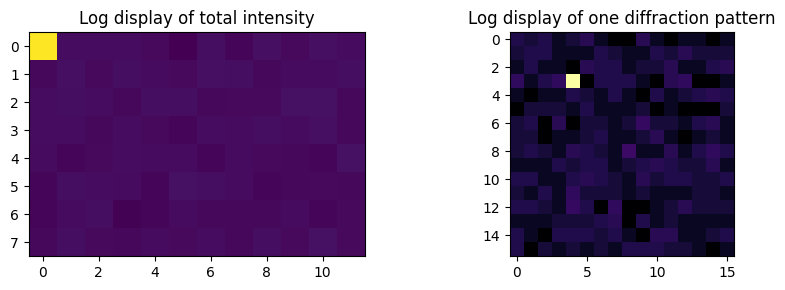

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].imshow(np.log1p(counts.sum(axis=(2, 3))), cmap="viridis")
axes[0].set_title("Log display of total intensity")
axes[1].imshow(np.log1p(counts[0, 0]), cmap="inferno")
axes[1].set_title("Log display of one diffraction pattern")
plt.tight_layout()
plt.show()

## Save once, then inspect readable calibration

`backend="cpu"` explicitly selects the reference encoder. Existing files are never overwritten. `io.inspect` reads the authenticated header, not the full detector array.

In [3]:
saved = folder / "synthetic.qem"
io.save(saved, counts, metadata=metadata, backend="cpu")
scientific = io.inspect(saved).metadata["scientific_metadata"]
print(json.dumps({
    "schema": scientific["schema"],
    "scan_row": scientific["axes"][0],
    "voltage": scientific["electron_microscope"]["electron_source/accelerating_voltage"],
    "source_metadata": scientific["source_metadata"],
}, indent=2))

{
  "schema": "quantem.scientific-metadata/2",
  "scan_row": {
    "name": "scan_row",
    "sampling": {
      "provenance": "source_metadata",
      "unit": "angstrom",
      "value": 0.4
    },
    "size": 8
  },
  "voltage": {
    "provenance": "source_metadata",
    "unit": "kV",
    "value": 300.0
  },
  "source_metadata": {
    "data_origin": "synthetic example, seed 7"
  }
}


## Reopen and check every count

This recovers the original array without requiring the original source path. Metadata stays separate from the measurements. Small examples are not meaningful compression benchmarks.

Every count exact: True
File integrity: verified codec layout: verified
Encoded file bytes: 12475


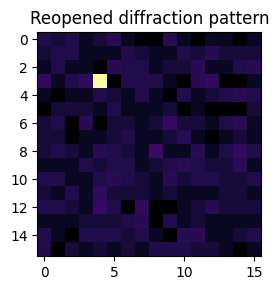

In [4]:
with io.load(saved, backend="cpu") as reopened:
    restored = reopened.data.copy()
    assert reopened.metadata["source_metadata"] == metadata["source_metadata"]
    np.testing.assert_array_equal(restored, counts)
report = validate_qem(saved)
print("Every count exact:", np.array_equal(restored, counts))
print("File integrity:", report["integrity"], "codec layout:", report["codec_layout"])
print("Encoded file bytes:", saved.stat().st_size)
fig, ax = plt.subplots(figsize=(4, 3))
ax.imshow(np.log1p(restored[0, 0]), cmap="inferno")
ax.set_title("Reopened diffraction pattern")
plt.tight_layout()
plt.show()

## Convert a NumPy file through the same public API

Qualified DM3/DM4 sources and EMPAD float-export XML/RAW files also have explicit CPU routes. See [the conversion guide](../api/qem-python.md) for supported layouts and limits. Never cast a detector's measurements simply to make a file pass an exporter.

In [5]:
np.save(folder / "source.npy", counts)
with io.load(folder / "source.npy", backend="cpu") as source:
    io.save(folder / "from-numpy.qem", source, metadata=metadata, backend="cpu")
with io.load(folder / "from-numpy.qem", backend="cpu") as reopened:
    np.testing.assert_array_equal(reopened.data, counts)
print("NumPy -> QEM -> NumPy: exact")
scratch.cleanup()
print("Temporary files removed:", not folder.exists())

NumPy -> QEM -> NumPy: exact
Temporary files removed: True


## Sharing public acquisitions later

This notebook contains no private data. Before publishing a Hugging Face gold-data derivative, verify the exact source repository, revision, license and hashes; review metadata for identifying information. Keep the original available and publish the conversion revision plus exactness checks. Nothing here uploads files.